<a href="https://colab.research.google.com/github/Dragonfly12347/Dragonfly12347/blob/main/Another_copy_of_Credit_Card_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...               0.0             

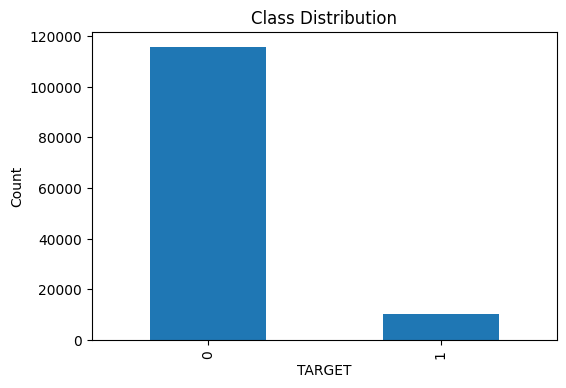

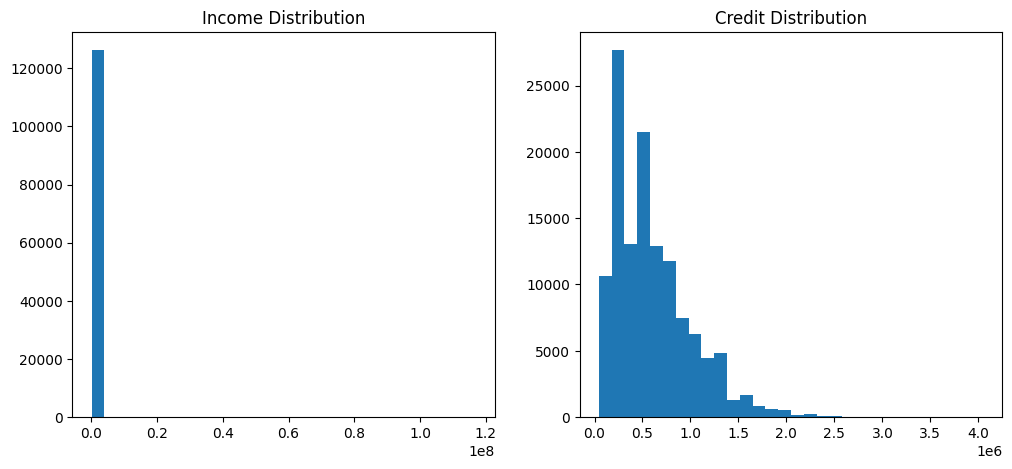

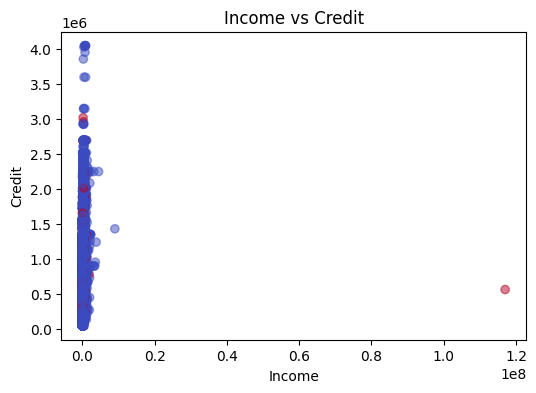

Best K: 14
Accuracy: 0.9183875698600816
Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     23169
           1       0.57      0.00      0.00      2060

    accuracy                           0.92     25229
   macro avg       0.74      0.50      0.48     25229
weighted avg       0.89      0.92      0.88     25229

Confusion Matrix:
[[23166     3]
 [ 2056     4]]


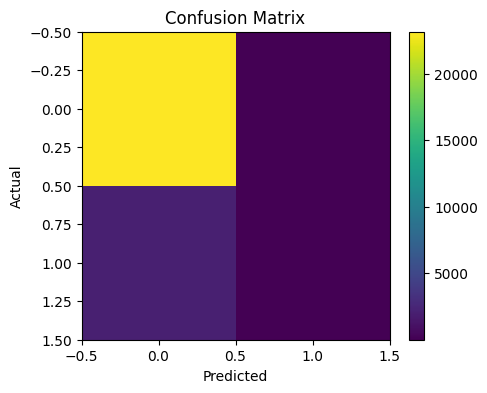

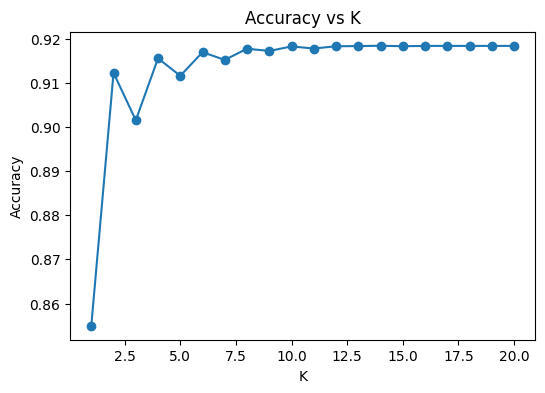


Best K value: 14
Best Accuracy: 0.9183875698600816


In [3]:
# |Credit Card Fraud Detection|
# application_data.csv

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.preprocessing import StandardScaler

# Load dataset
df=pd.read_csv('application_data.csv')

# Explore data
print(df.head())
print(df['TARGET'].value_counts())

# Graph-1: Class distribution
plt.figure(figsize=(6,4))
df['TARGET'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("TARGET")
plt.ylabel("Count")
plt.show()

# Graph-2: Income and Credit distribution
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['AMT_INCOME_TOTAL'],bins=30)
plt.title("Income Distribution")
plt.subplot(1,2,2)
plt.hist(df['AMT_CREDIT'],bins=30)
plt.title("Credit Distribution")
plt.show()

# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df['AMT_INCOME_TOTAL'],df['AMT_CREDIT'],c=df['TARGET'],cmap='coolwarm',alpha=0.5)
plt.title("Income vs Credit")
plt.xlabel("Income")
plt.ylabel("Credit")
plt.show()

# Select features
X=df[['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE']].fillna(0)
y=df['TARGET']

# Feature scaling
scaler=StandardScaler()
X=scaler.fit_transform(X)

# Split data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Find best K
accuracy=[]
k_range=range(1,21)
for k in k_range:
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    accuracy.append(accuracy_score(y_test,pred))

best_k=k_range[np.argmax(accuracy)]

# Train final model
knn=KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train,y_train)

# Prediction
y_pred=knn.predict(X_test)

# Results
print("Best K:",best_k)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Classification Report:")
print(classification_report(y_test,y_pred))

cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

# Graph-3: Confusion matrix
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

# Graph-4: Accuracy vs K
plt.figure(figsize=(6,4))
plt.plot(k_range,accuracy,marker='o')
plt.title("Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

# Best Accuracy
best_k = k_range[np.argmax(accuracy)]
best_acc = max(accuracy)
print("\nBest K value:", best_k)
print("Best Accuracy:", best_acc)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')